In [1]:
# Upload kaggle.json manually when prompted
from google.colab import files
files.upload()

# Move kaggle.json to the correct folder
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API authenticated!")

Saving kaggle.json to kaggle.json
Kaggle API authenticated!


In [2]:
# Create datasets folder
!mkdir -p /content/datasets

# Download the VITON-HD dataset (replace dataset name if needed)
!kaggle datasets download -d marquis03/high-resolution-viton-zalando-dataset -p /content/datasets

Dataset URL: https://www.kaggle.com/datasets/marquis03/high-resolution-viton-zalando-dataset
License(s): CC-BY-NC-SA-4.0


In [2]:
# Unzip it
!unzip -q /content/datasets/high-resolution-viton-zalando-dataset.zip -d /content/datasets/viton_hd

print("VITON-HD dataset downloaded and extracted!")

VITON-HD dataset downloaded and extracted!


In [61]:
import cv2
import numpy as np
import json
from skimage.transform import PiecewiseAffineTransform, warp
import matplotlib.pyplot as plt
import os
import torch
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F

In [23]:
def plot_keypoints(image, keypoints):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for (x, y) in keypoints:
        plt.plot(x, y, 'ro')
    plt.title('Keypoints')
    plt.axis('off')
    plt.show()

In [36]:
def plot_histograms(person_img, warped_clothing):
    colors = ('b', 'g', 'r')
    plt.figure(figsize=(12, 6))

    for i, color in enumerate(colors):
        person_hist = cv2.calcHist([person_img], [i], None, [256], [0, 256])
        clothing_hist = cv2.calcHist([warped_clothing], [i], None, [256], [0, 256])

        plt.plot(person_hist, color=color, linestyle='--', label=f'Person {color.upper()}')
        plt.plot(clothing_hist, color=color, label=f'Clothing {color.upper()}')

    plt.title('Histogram Comparison: Person vs Warped Clothing')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [46]:
# --- Visualization Cell ---
def visualize_pipeline(person_img, clothing_img, warped_clothing, mask, final_tryon):
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(person_img, cv2.COLOR_BGR2RGB))
    plt.title('Person Image')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(cv2.cvtColor(clothing_img, cv2.COLOR_BGR2RGB))
    plt.title('Clothing Image')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(cv2.cvtColor(warped_clothing, cv2.COLOR_BGR2RGB))
    plt.title('Warped Clothing')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(mask, cmap='gray')
    plt.title('Generated Mask')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(cv2.cvtColor(final_tryon, cv2.COLOR_BGR2RGB))
    plt.title('Final Try-On Result')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [53]:
# --- Helper Functions ---
def resize_with_padding(image, target_size=(256, 192)):
    h, w = image.shape[:2]
    target_h, target_w = target_size

    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)

    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    padded_image = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    pad_x = (target_w - new_w) // 2
    pad_y = (target_h - new_h) // 2

    padded_image[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized_image

    return padded_image, (h, w), (new_h, new_w), (pad_x, pad_y)

def extract_semantic_person_keypoints(json_path, original_size, resized_size, padded_size, padding):
    important_indexes = [5, 2, 11, 8, 1]  # left_shoulder, right_shoulder, left_hip, right_hip, neck

    with open(json_path, 'r') as f:
        data = json.load(f)

    keypoints = []
    if data['people']:
        pose_keypoints = data['people'][0]['pose_keypoints_2d']
        orig_h, orig_w = original_size
        new_h, new_w = resized_size
        pad_x, pad_y = padding

        for idx in important_indexes:
            x = pose_keypoints[3 * idx]
            y = pose_keypoints[3 * idx + 1]
            c = pose_keypoints[3 * idx + 2]
            if c > 0.1:
                scaled_x = int(x * new_w / orig_w) + pad_x
                scaled_y = int(y * new_h / orig_h) + pad_y
                keypoints.append((scaled_x, scaled_y))
            else:
                fallback_x = new_w // 2 + pad_x
                fallback_y = new_h // 2 + pad_y
                keypoints.append((fallback_x, fallback_y))

        # Create mid-hip by averaging hips
        mid_hip_x = (keypoints[2][0] + keypoints[3][0]) // 2
        mid_hip_y = (keypoints[2][1] + keypoints[3][1]) // 2
        keypoints.append((mid_hip_x, mid_hip_y))

    return keypoints

def synthesize_semantic_cloth_keypoints(image_shape):
    h, w = image_shape[:2]
    keypoints = [
        (int(w * 0.25), int(h * 0.2)),  # Left shoulder
        (int(w * 0.75), int(h * 0.2)),  # Right shoulder
        (int(w * 0.25), int(h * 0.8)),  # Left waist
        (int(w * 0.75), int(h * 0.8)),  # Right waist
        (int(w * 0.5), int(h * 0.3)),   # Center chest
        (int(w * 0.5), int(h * 0.7))    # Center waist
    ]
    return keypoints

def estimate_tps_transform(source_points, target_points):
    tform = PiecewiseAffineTransform()
    tform.estimate(np.array(source_points), np.array(target_points))
    return tform

def warp_clothing(clothing_img_bgr, tform, output_shape):
    clothing_img_rgb = cv2.cvtColor(clothing_img_bgr, cv2.COLOR_BGR2RGB)
    clothing_img_rgb = clothing_img_rgb / 255.0
    warped = warp(clothing_img_rgb, tform, output_shape=output_shape, preserve_range=True)
    warped = (warped * 255.0).clip(0, 255).astype(np.uint8)
    warped = cv2.GaussianBlur(warped, (3, 3), 0.5)
    return warped

def create_enhanced_mask(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 10, 50)
    kernel = np.ones((5, 5), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    filled = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel)
    filled = cv2.morphologyEx(filled, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    _, mask = cv2.threshold(filled, 1, 255, cv2.THRESH_BINARY)
    mask = cv2.medianBlur(mask, 5)
    return mask

def feather_mask(mask, feather_amount=5):
    blurred = cv2.GaussianBlur(mask, (feather_amount, feather_amount), 0)
    _, soft_mask = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
    return soft_mask

def blend_images(base_img, warped_clothing, mask):
    mask = feather_mask(mask)
    center = (base_img.shape[1] // 2, base_img.shape[0] // 2)
    blended = cv2.seamlessClone(warped_clothing, base_img, mask, center, cv2.NORMAL_CLONE)
    return blended

def plot_histograms(person_img, warped_clothing):
    colors = ('b', 'g', 'r')
    plt.figure(figsize=(12, 6))
    for i, color in enumerate(colors):
        person_hist = cv2.calcHist([person_img], [i], None, [256], [0, 256])
        clothing_hist = cv2.calcHist([warped_clothing], [i], None, [256], [0, 256])
        plt.plot(person_hist, color=color, linestyle='--', label=f'Person {color.upper()}')
        plt.plot(clothing_hist, color=color, label=f'Clothing {color.upper()}')
    plt.title('Histogram Comparison: Person vs Warped Clothing')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [69]:
# --- Main Pipeline ---
def traditional_tryon_pipeline(person_img_path, person_json_path, clothing_img_path):
    original_person_img = cv2.imread(person_img_path)
    person_img, original_size, resized_size, padding = resize_with_padding(original_person_img)
    clothing_img = cv2.imread(clothing_img_path)
    clothing_img, _, _, _ = resize_with_padding(clothing_img)

    person_keypoints = extract_semantic_person_keypoints(person_json_path, original_size, resized_size, (256, 192), padding)
    clothing_keypoints = synthesize_semantic_cloth_keypoints(clothing_img.shape)

    if len(person_keypoints) != len(clothing_keypoints):
        raise ValueError(f"Mismatch: {len(person_keypoints)} person points vs {len(clothing_keypoints)} cloth points")

    tps_transform = estimate_tps_transform(clothing_keypoints, person_keypoints)
    warped_clothing = warp_clothing(clothing_img, tps_transform, output_shape=person_img.shape[:2])
    warped_clothing_bgr = cv2.cvtColor(warped_clothing, cv2.COLOR_RGB2BGR)

    # plot_histograms(person_img, warped_clothing_bgr)

    mask = create_enhanced_mask(warped_clothing_bgr)
    final_tryon = blend_images(person_img, warped_clothing_bgr, mask)

    return person_img, clothing_img, warped_clothing_bgr, mask, final_tryon

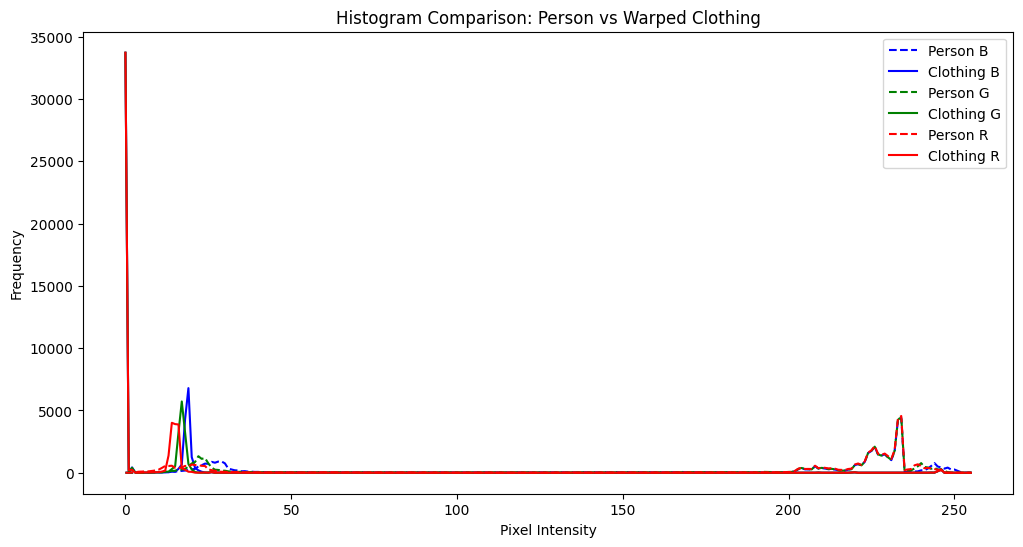

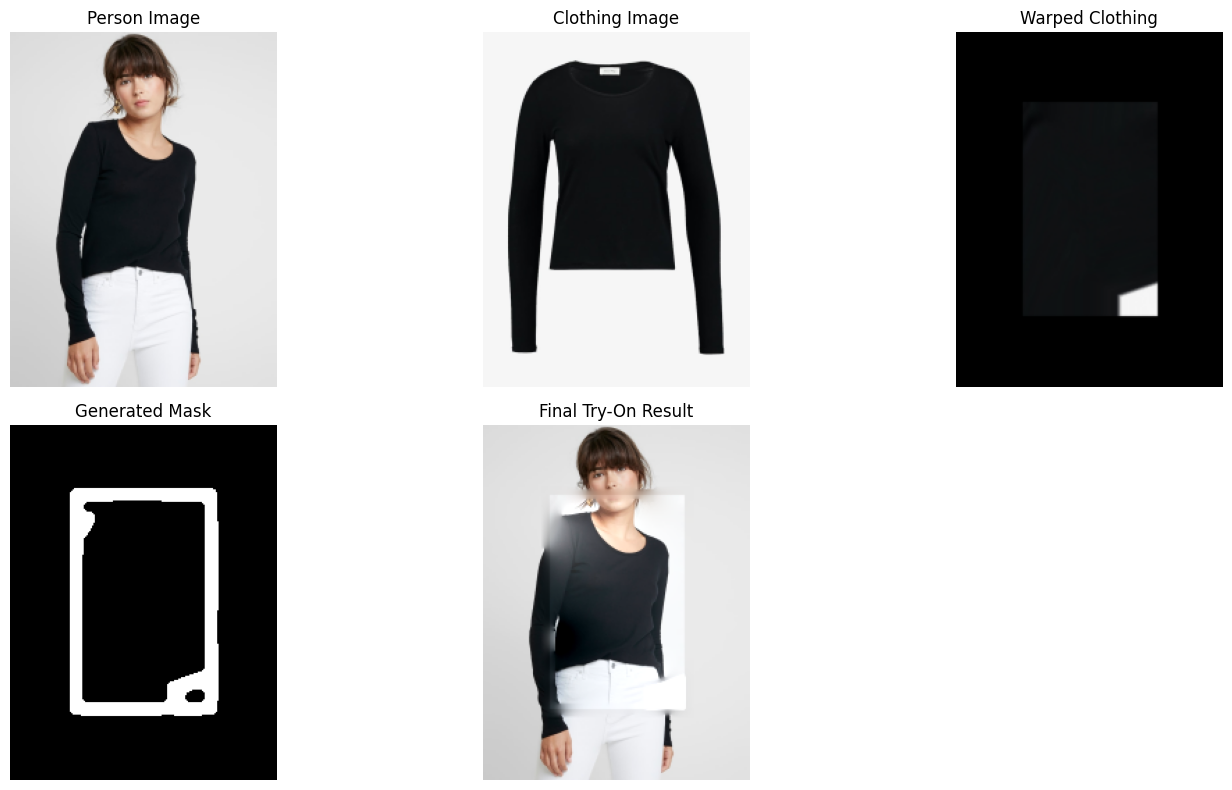

In [68]:
# --- Example Usage ---
person_img, clothing_img, warped_clothing, mask, final_tryon = traditional_tryon_pipeline(
    '/content/datasets/viton_hd/test/image/00006_00.jpg',
    '/content/datasets/viton_hd/test/openpose_json/00006_00_keypoints.json',
    '/content/datasets/viton_hd/test/cloth/00006_00.jpg'
)
visualize_pipeline(person_img, clothing_img, warped_clothing, mask, final_tryon)

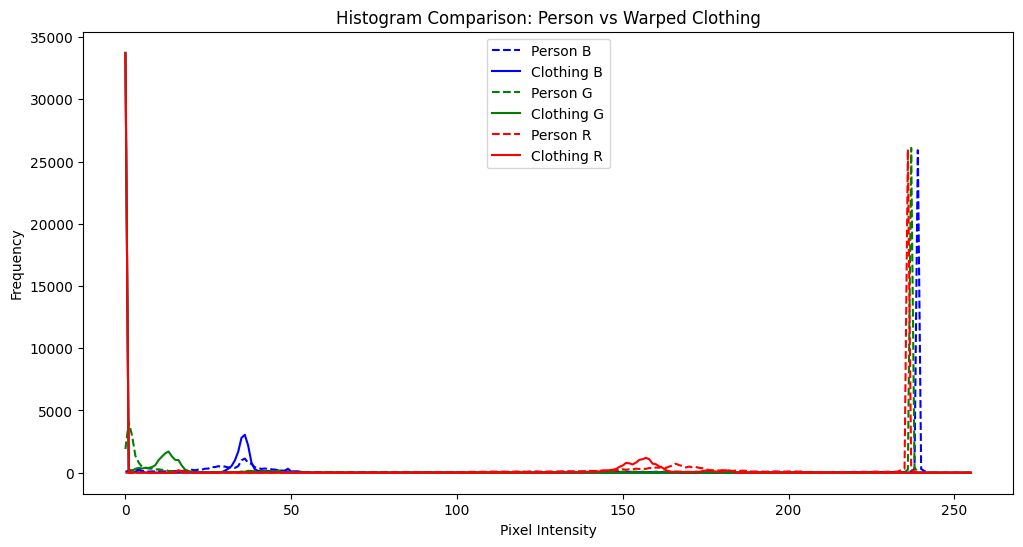

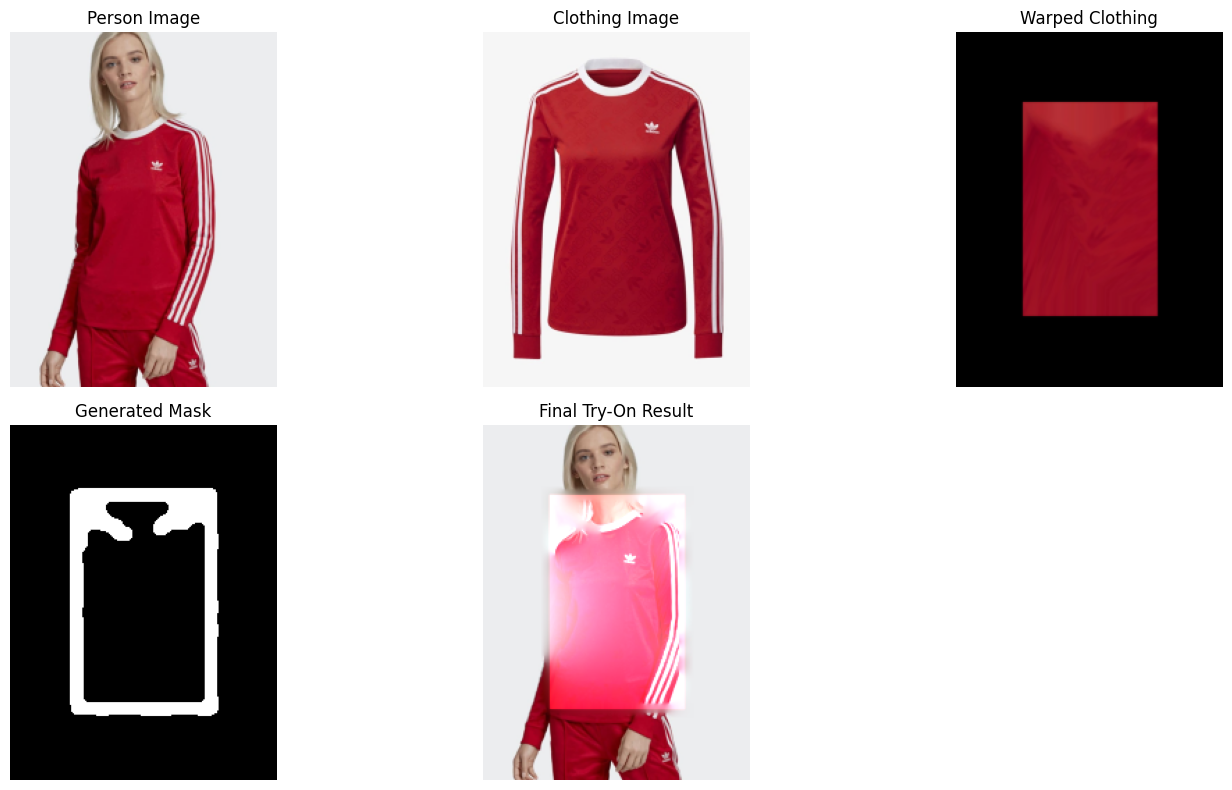

In [55]:
# --- Example Usage ---
person_img, clothing_img, warped_clothing, mask, final_tryon = traditional_tryon_pipeline(
    '/content/datasets/viton_hd/test/image/00008_00.jpg',
    '/content/datasets/viton_hd/test/openpose_json/00008_00_keypoints.json',
    '/content/datasets/viton_hd/test/cloth/00008_00.jpg'
)
visualize_pipeline(person_img, clothing_img, warped_clothing, mask, final_tryon)

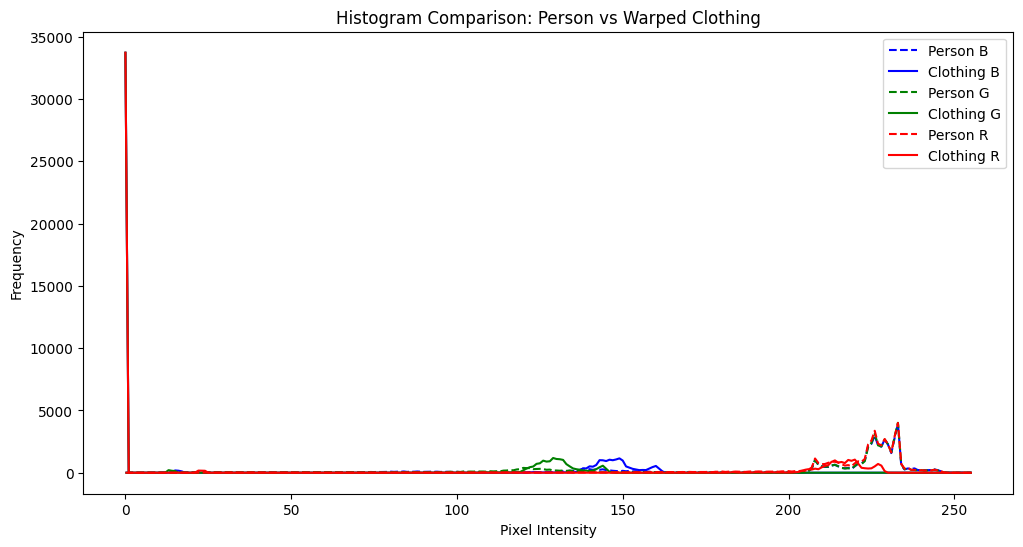

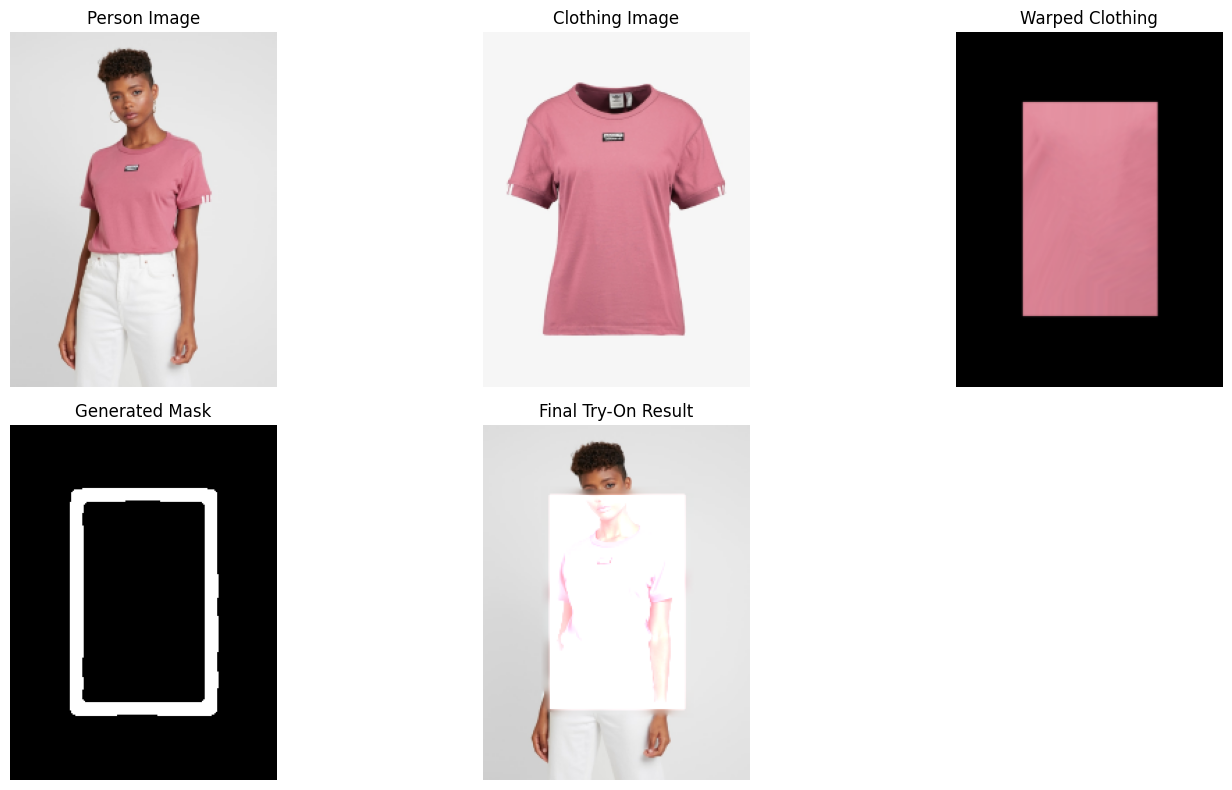

In [56]:
# --- Example Usage ---
person_img, clothing_img, warped_clothing, mask, final_tryon = traditional_tryon_pipeline(
    '/content/datasets/viton_hd/test/image/00013_00.jpg',
    '/content/datasets/viton_hd/test/openpose_json/00013_00_keypoints.json',
    '/content/datasets/viton_hd/test/cloth/00013_00.jpg'
)
visualize_pipeline(person_img, clothing_img, warped_clothing, mask, final_tryon)

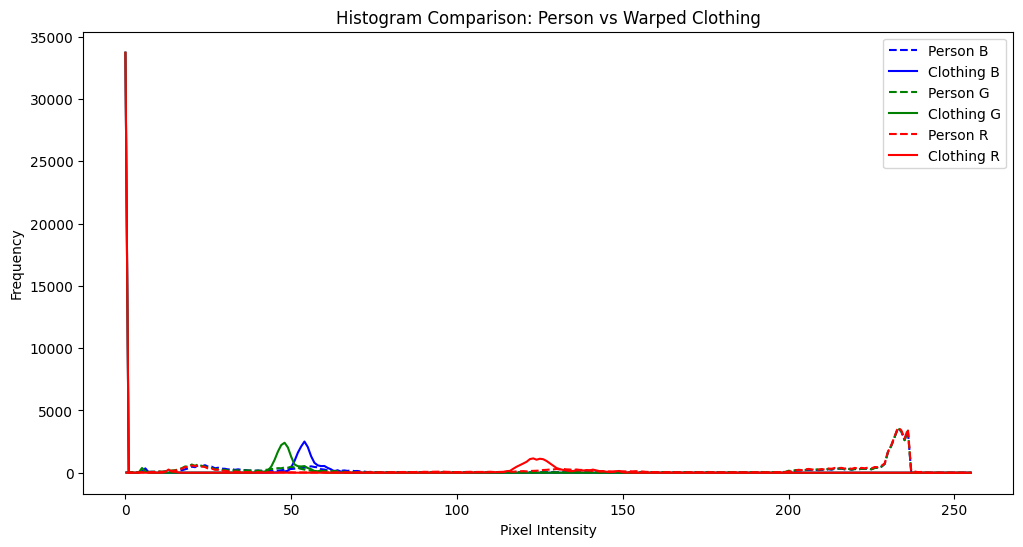

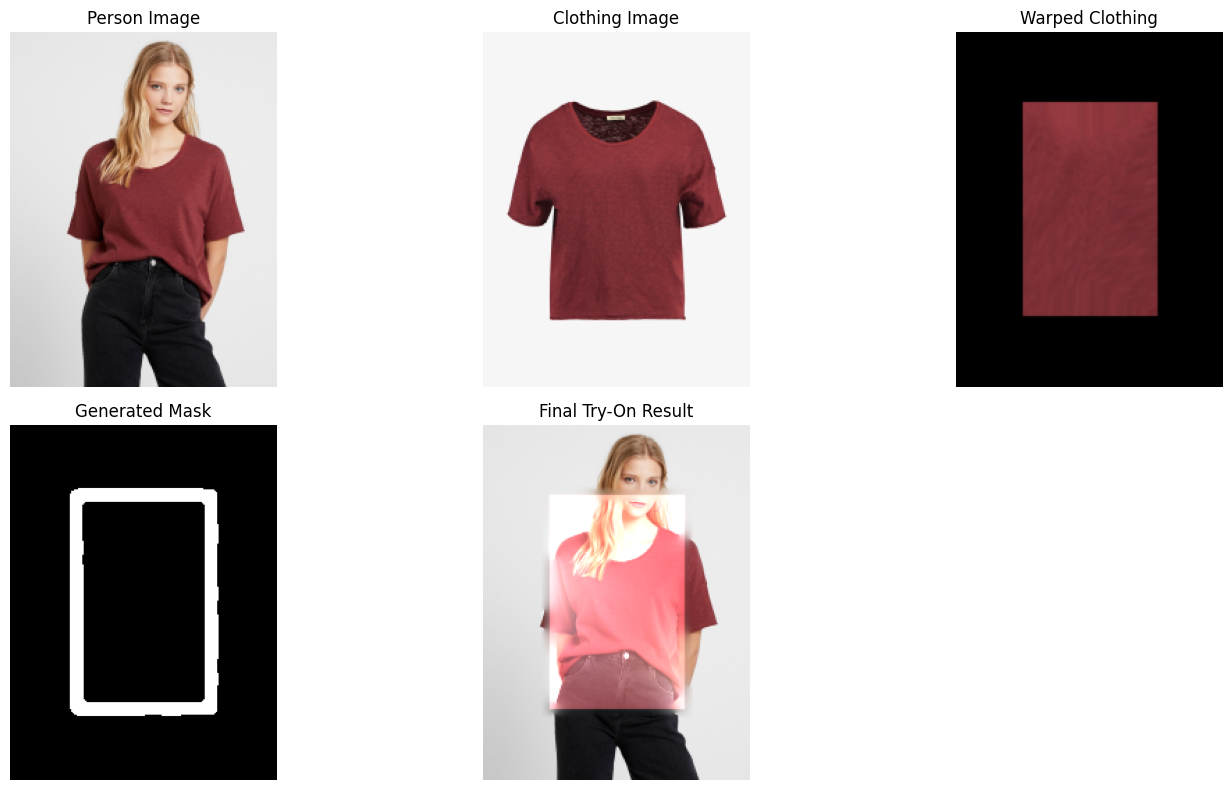

In [57]:
# --- Example Usage ---
person_img, clothing_img, warped_clothing, mask, final_tryon = traditional_tryon_pipeline(
    '/content/datasets/viton_hd/test/image/00017_00.jpg',
    '/content/datasets/viton_hd/test/openpose_json/00017_00_keypoints.json',
    '/content/datasets/viton_hd/test/cloth/00017_00.jpg'
)
visualize_pipeline(person_img, clothing_img, warped_clothing, mask, final_tryon)

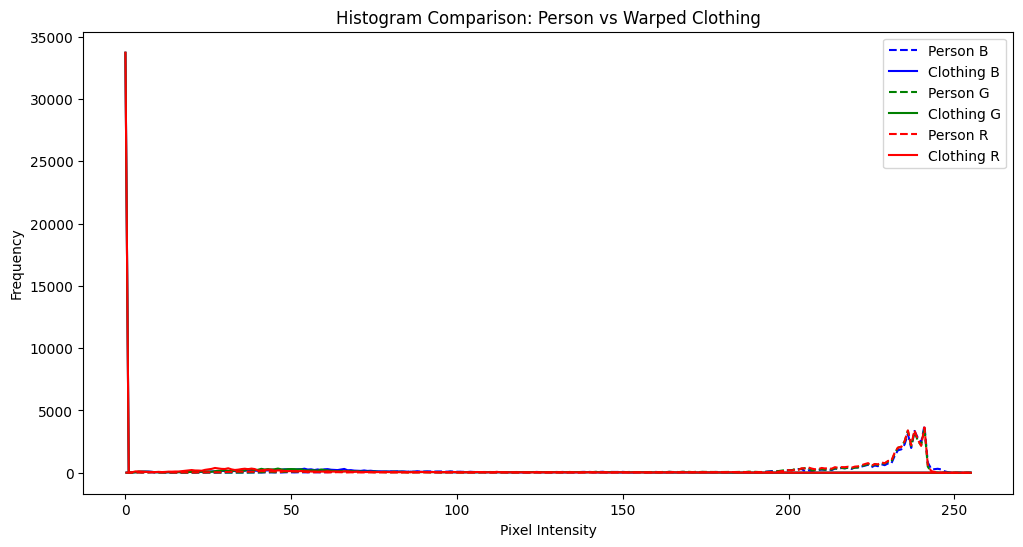

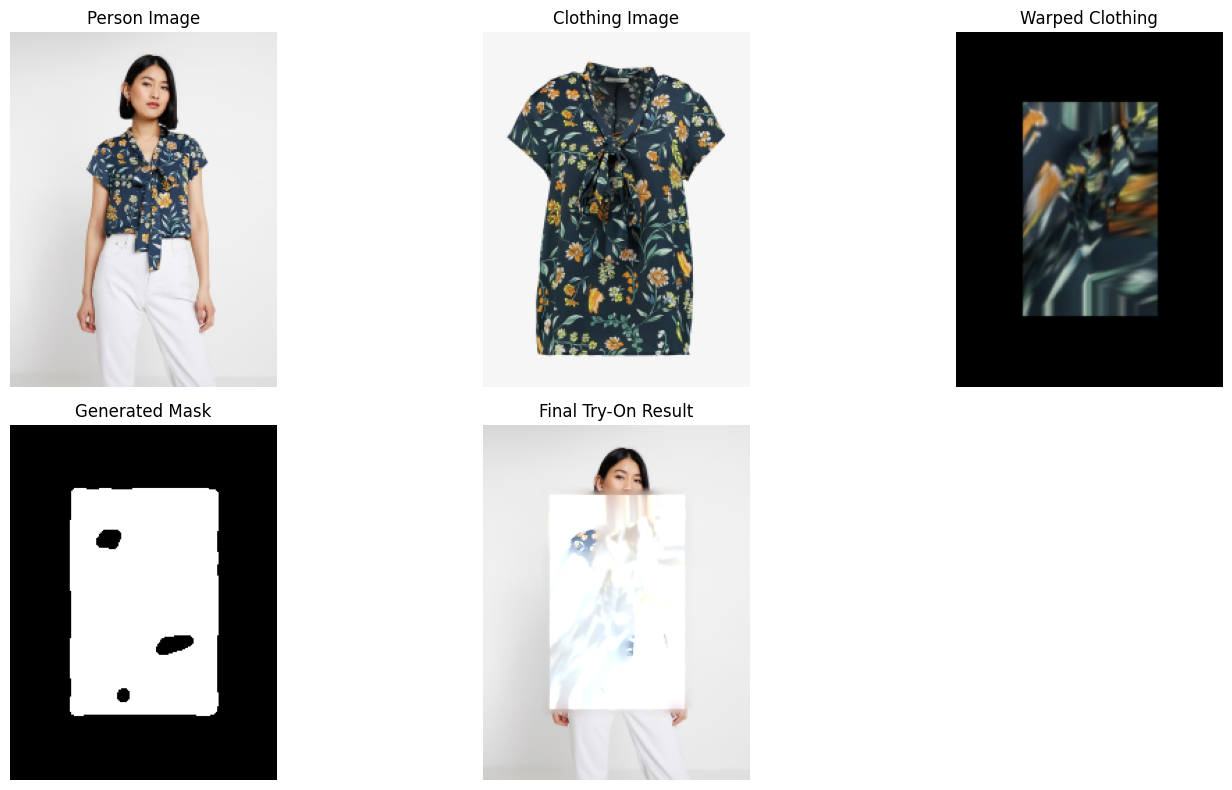

In [58]:
# --- Example Usage ---
person_img, clothing_img, warped_clothing, mask, final_tryon = traditional_tryon_pipeline(
    '/content/datasets/viton_hd/test/image/00205_00.jpg',
    '/content/datasets/viton_hd/test/openpose_json/00205_00_keypoints.json',
    '/content/datasets/viton_hd/test/cloth/00205_00.jpg'
)
visualize_pipeline(person_img, clothing_img, warped_clothing, mask, final_tryon)

In [70]:
# --- Evaluation Functions ---
def compute_ssim(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    score, _ = ssim(gray1, gray2, full=True)
    return score

def compute_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

def compute_edge_preservation(img1, img2):
    edges1 = cv2.Canny(img1, 100, 200)
    edges2 = cv2.Canny(img2, 100, 200)
    score, _ = ssim(edges1, edges2, full=True)
    return score

def compute_fid(real_images, gen_images):
    real_mean = real_images.mean(dim=[0,2,3])
    gen_mean = gen_images.mean(dim=[0,2,3])
    fid = F.mse_loss(real_mean, gen_mean).item()
    return fid

In [71]:
# --- Batch Processing ---
def process_test_pairs(test_pairs_file, base_image_dir, base_cloth_dir, base_openpose_json_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    real_images_list = []
    gen_images_list = []
    ssim_scores = []
    psnr_scores = []
    edge_scores = []

    metrics_log_path = os.path.join(output_dir, 'metrics_log.txt')
    error_log_path = os.path.join(output_dir, 'error_log.txt')

    with open(test_pairs_file, 'r') as f:
        lines = f.readlines()

    with open(metrics_log_path, 'w') as log_file, open(error_log_path, 'w') as error_log_file:
        for line in lines:
            person_filename, cloth_filename = line.strip().split()

            person_img_path = os.path.join(base_image_dir, person_filename)
            clothing_img_path = os.path.join(base_cloth_dir, cloth_filename)
            person_json_path = os.path.join(base_openpose_json_dir, person_filename.replace('.jpg', '_keypoints.json'))

            try:
                # Make sure your traditional_tryon_pipeline returns properly
                person_img, clothing_img, warped_clothing, mask, tryon_result = traditional_tryon_pipeline(
                    person_img_path, person_json_path, clothing_img_path
                )

                base_name = f"{os.path.splitext(person_filename)[0]}_{os.path.splitext(cloth_filename)[0]}"

                tryon_save_path = os.path.join(output_dir, f"tryon_{base_name}.jpg")
                mask_save_path = os.path.join(output_dir, f"mask_{base_name}.png")
                warped_save_path = os.path.join(output_dir, f"warped_{base_name}.jpg")

                cv2.imwrite(tryon_save_path, tryon_result)
                cv2.imwrite(mask_save_path, mask)
                cv2.imwrite(warped_save_path, warped_clothing)

                print(f"Saved: {tryon_save_path}, {mask_save_path}, {warped_save_path}")

                # For evaluation
                original = cv2.imread(person_img_path)
                original = cv2.resize(original, (192, 256))
                tryon_result_resized = cv2.resize(tryon_result, (192, 256))

                real_images_list.append(original)
                gen_images_list.append(tryon_result_resized)

                # Compute per-image metrics
                ssim = compute_ssim(original, tryon_result_resized)
                psnr = compute_psnr(original, tryon_result_resized)
                edge = compute_edge_preservation(original, tryon_result_resized)

                ssim_scores.append(ssim)
                psnr_scores.append(psnr)
                edge_scores.append(edge)

                log_file.write(f"{base_name} | SSIM: {ssim:.4f} | PSNR: {psnr:.2f} | Edge Preservation: {edge:.4f}\n")

            except Exception as e:
                error_message = f"Failed for {person_filename} and {cloth_filename}: {e}\n"
                print(error_message)
                error_log_file.write(error_message)

    # Batch-level FID
    real_images_tensor = torch.tensor(np.array(real_images_list)).permute(0, 3, 1, 2).float() / 255.0
    gen_images_tensor = torch.tensor(np.array(gen_images_list)).permute(0, 3, 1, 2).float() / 255.0

    fid_score = compute_fid(real_images_tensor, gen_images_tensor)

    print(f"FID Score across all samples: {fid_score:.4f}")

    with open(metrics_log_path, 'a') as log_file:
        log_file.write(f"\nAverage SSIM: {np.mean(ssim_scores):.4f}\n")
        log_file.write(f"Average PSNR: {np.mean(psnr_scores):.2f}\n")
        log_file.write(f"Average Edge Preservation: {np.mean(edge_scores):.4f}\n")
        log_file.write(f"FID: {fid_score:.4f}\n")

    print("Batch Processing and Evaluation Completed Successfully!")

In [72]:
test_pairs_file = "/content/datasets/viton_hd/test_pairs.txt"
base_image_dir = "/content/datasets/viton_hd/test/image"
base_cloth_dir = "/content/datasets/viton_hd/test/cloth"
base_openpose_json_dir = "/content/datasets/viton_hd/test/openpose_json"
output_dir = "/content/Results/test/tryon_results"

process_test_pairs(test_pairs_file, base_image_dir, base_cloth_dir,
                    base_openpose_json_dir, output_dir)

Saved: /content/Results/test/tryon_results/tryon_05006_00_11001_00.jpg, /content/Results/test/tryon_results/mask_05006_00_11001_00.png, /content/Results/test/tryon_results/warped_05006_00_11001_00.jpg
Saved: /content/Results/test/tryon_results/tryon_02532_00_14096_00.jpg, /content/Results/test/tryon_results/mask_02532_00_14096_00.png, /content/Results/test/tryon_results/warped_02532_00_14096_00.jpg
Saved: /content/Results/test/tryon_results/tryon_03921_00_08015_00.jpg, /content/Results/test/tryon_results/mask_03921_00_08015_00.png, /content/Results/test/tryon_results/warped_03921_00_08015_00.jpg
Saved: /content/Results/test/tryon_results/tryon_12419_00_01944_00.jpg, /content/Results/test/tryon_results/mask_12419_00_01944_00.png, /content/Results/test/tryon_results/warped_12419_00_01944_00.jpg
Saved: /content/Results/test/tryon_results/tryon_12562_00_14025_00.jpg, /content/Results/test/tryon_results/mask_12562_00_14025_00.png, /content/Results/test/tryon_results/warped_12562_00_14025_00

/usr/local/lib/python3.11/dist-packages/numpy/_core/numeric.py:452: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
<ipython-input-53-a2aead8b986a>:73: RuntimeWarning: invalid value encountered in cast
  warped = (warped * 255.0).clip(0, 255).astype(np.uint8)


Saved: /content/Results/test/tryon_results/tryon_06123_00_09026_00.jpg, /content/Results/test/tryon_results/mask_06123_00_09026_00.png, /content/Results/test/tryon_results/warped_06123_00_09026_00.jpg
Saved: /content/Results/test/tryon_results/tryon_04514_00_06442_00.jpg, /content/Results/test/tryon_results/mask_04514_00_06442_00.png, /content/Results/test/tryon_results/warped_04514_00_06442_00.jpg
Saved: /content/Results/test/tryon_results/tryon_03068_00_01992_00.jpg, /content/Results/test/tryon_results/mask_03068_00_01992_00.png, /content/Results/test/tryon_results/warped_03068_00_01992_00.jpg
Saved: /content/Results/test/tryon_results/tryon_09790_00_08053_00.jpg, /content/Results/test/tryon_results/mask_09790_00_08053_00.png, /content/Results/test/tryon_results/warped_09790_00_08053_00.jpg
Saved: /content/Results/test/tryon_results/tryon_01293_00_01923_00.jpg, /content/Results/test/tryon_results/mask_01293_00_01923_00.png, /content/Results/test/tryon_results/warped_01293_00_01923_00

In [73]:
!zip -r Results_Traditional.zip /content/Results

Streaming output truncated to the last 5000 lines.
updating: content/Results/test/tryon_results/mask_10731_00_06871_00.png (deflated 53%)
updating: content/Results/test/tryon_results/mask_14112_00_04393_00.png (deflated 73%)
updating: content/Results/test/tryon_results/mask_01961_00_13437_00.png (deflated 66%)
updating: content/Results/test/tryon_results/mask_01691_00_13036_00.png (deflated 58%)
updating: content/Results/test/tryon_results/tryon_13204_00_00877_00.jpg (deflated 2%)
updating: content/Results/test/tryon_results/warped_09148_00_01644_00.jpg (deflated 15%)
updating: content/Results/test/tryon_results/tryon_03268_00_04666_00.jpg (deflated 2%)
updating: content/Results/test/tryon_results/mask_05325_00_02507_00.png (deflated 50%)
updating: content/Results/test/tryon_results/mask_10090_00_00121_00.png (deflated 52%)
updating: content/Results/test/tryon_results/warped_02727_00_00713_00.jpg (deflated 9%)
updating: content/Results/test/tryon_results/mask_07236_00_10258_00.png (def

In [74]:
from google.colab import files
files.download('Results_Traditional.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>